# example figure

In [3]:
# ---- 方式 A：字典（便于按名字取数）----
# 含每个 seed 的具体数值（单位：% of fully-supervised at 20% labels）
data_dict = {
    "D1": {
        "Baseline": {0: 82.3, 1: 81.5, 2: 83.7, 3: 82.9, 4: 83.0},
        "ALBE":     {0: 90.8, 1: 91.2, 2: 89.6, 3: 91.0, 4: 90.4},
    },
    "D2": {
        "Baseline": {0: 80.6, 1: 83.1, 2: 82.8, 3: 84.9, 4: 83.4},
        "ALBE":     {0: 89.7, 1: 90.2, 2: 88.9, 3: 91.0, 4: 90.5},
    },
    "D3": {
        "Baseline": {0: 83.1, 1: 85.9, 2: 84.7, 3: 86.3, 4: 82.9},
        "ALBE":     {0: 91.5, 1: 92.8, 2: 93.2, 3: 90.7, 4: 92.1},
    },
    "D4": {
        "Baseline": {0: 86.0, 1: 87.5, 2: 88.9, 3: 89.3, 4: 90.0},
        "ALBE":     {0: 92.2, 1: 93.0, 2: 94.1, 3: 95.3, 4: 93.6},
    },
}

# 如果你需要 DataFrame：
import pandas as pd
rows = []
for ds, methods in data_dict.items():
    for m, seedmap in methods.items():
        for s, v in seedmap.items():
            rows.append({"dataset": ds, "method": m, "seed": s, "pct_of_supervised": v})
df = pd.DataFrame(rows).sort_values(["dataset","method","seed"]).reset_index(drop=True)

Saved to: single_panel_ALBE_vs_baseline.svg  /  single_panel_ALBE_vs_baseline.png


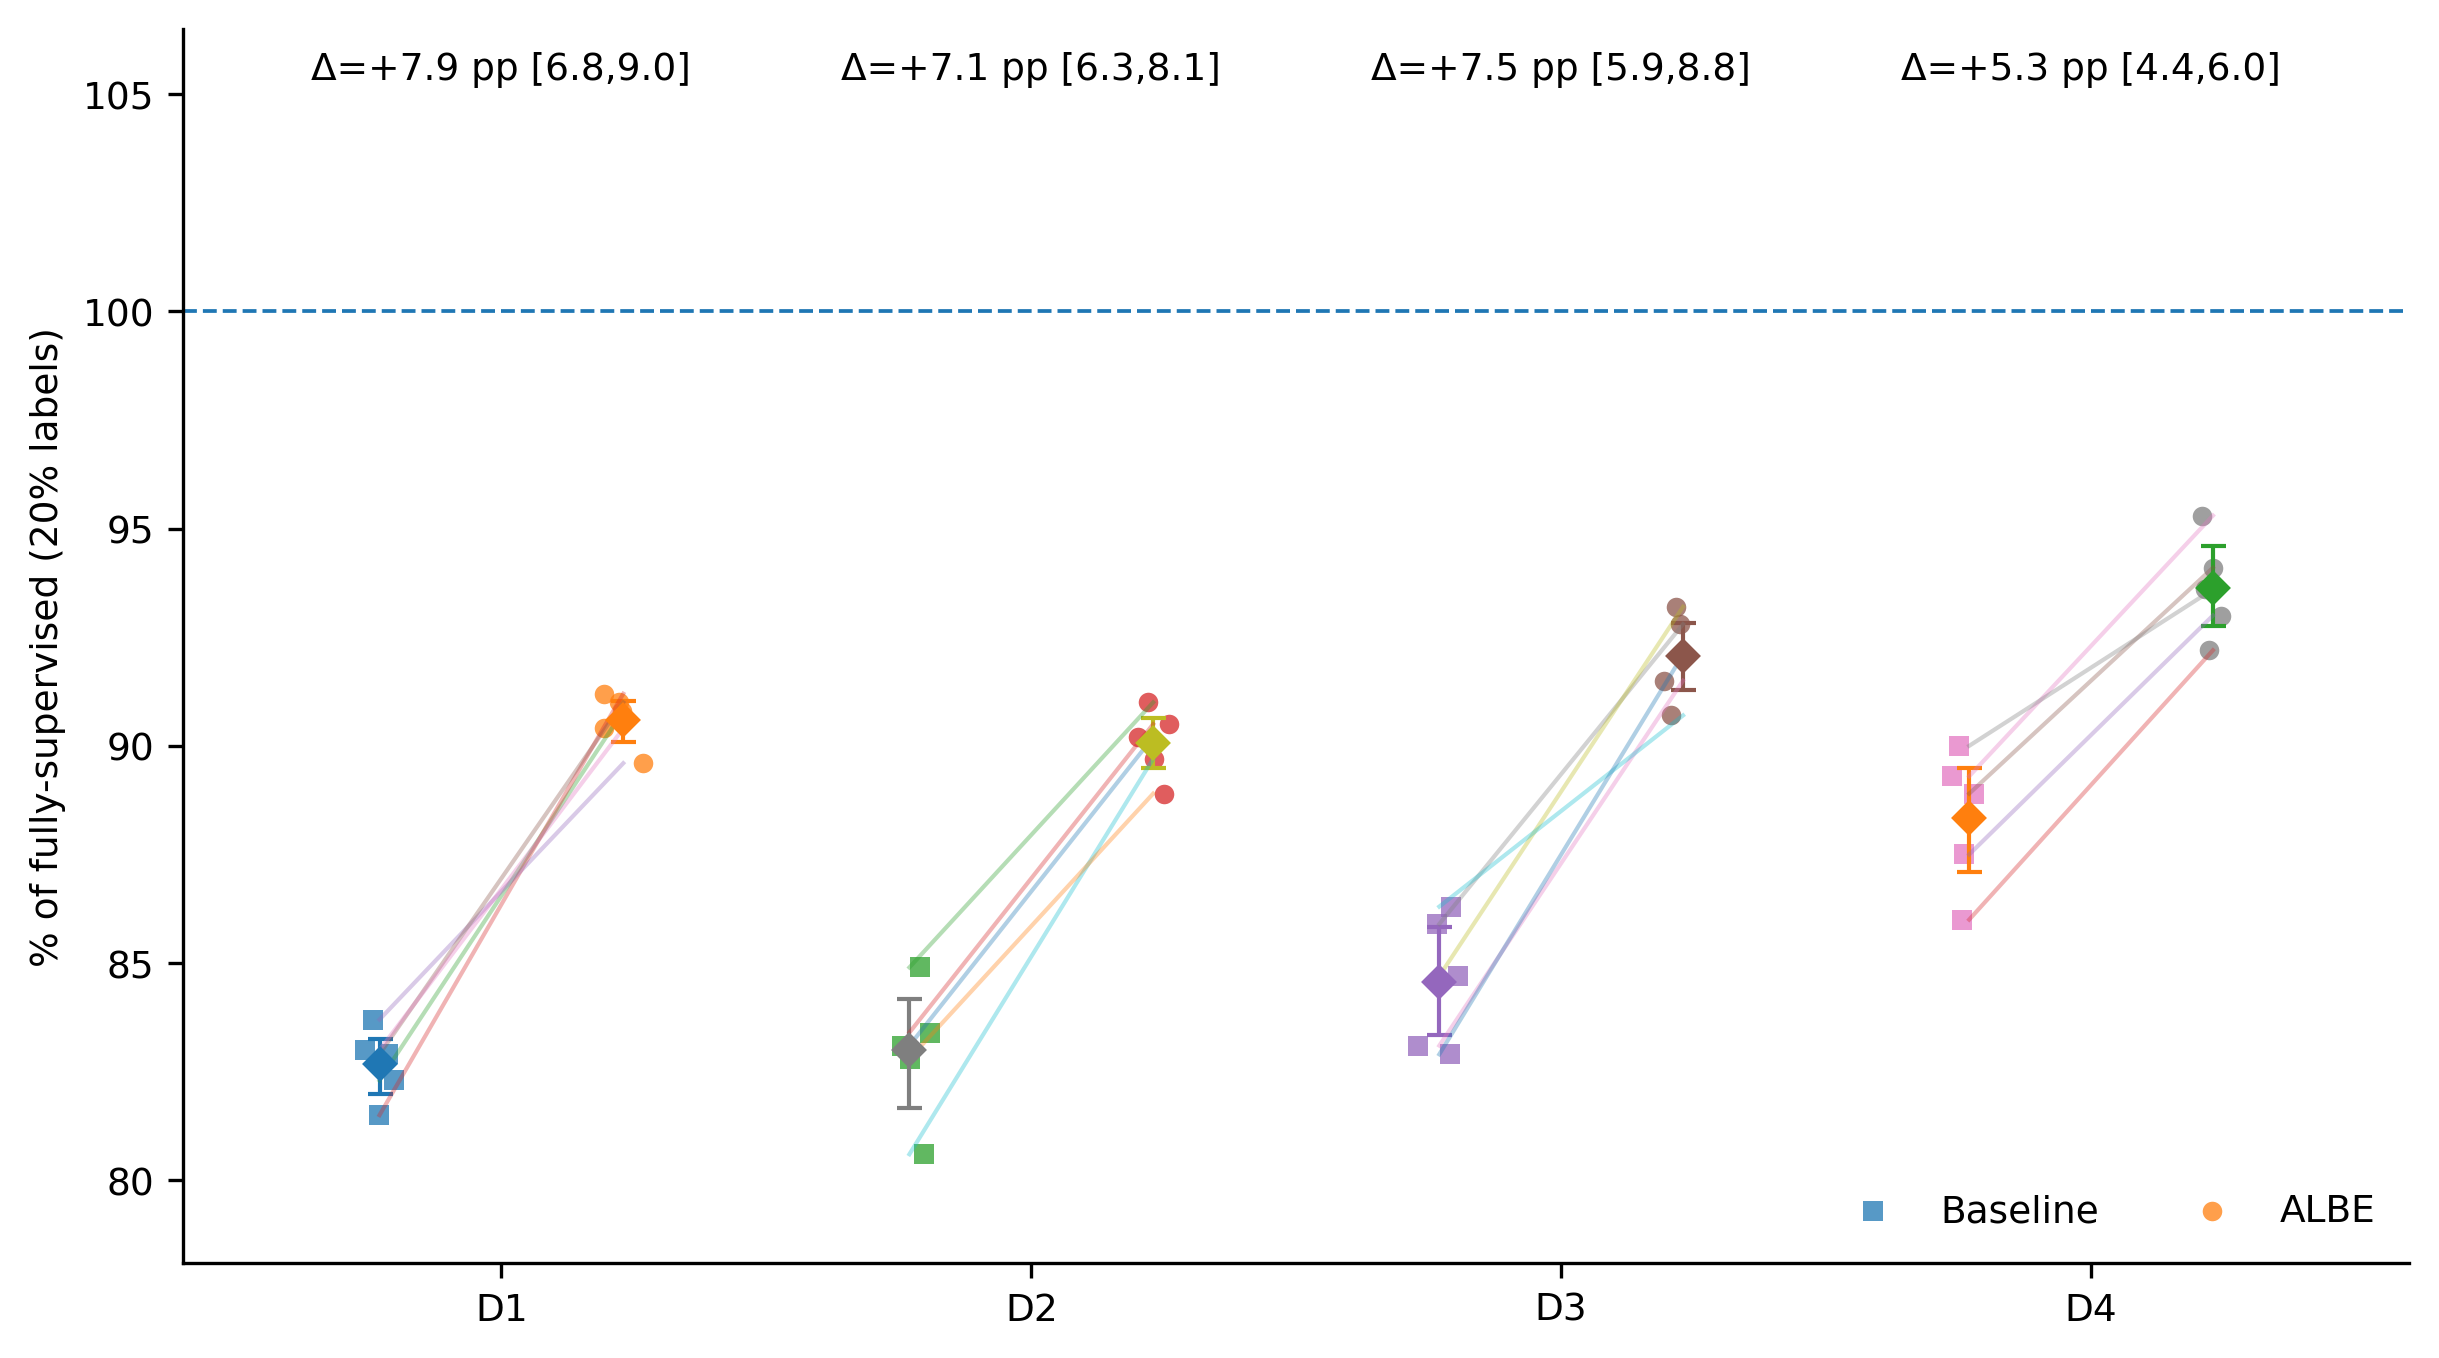

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Single-panel figure for: 20% labels performance as % of fully-supervised (100%)
- Jittered seed scatter for both methods (Baseline, ALBE)
- Mean ± 95% bootstrap CI (diamond markers)
- Seed-wise pairing lines (Baseline -> ALBE)
- Horizontal 100% reference line
- Per-dataset Δ annotation: mean(ALBE - Baseline) ± 95% CI [pp]

Input format (DataFrame):
  columns = ["dataset", "method", "seed", "pct_of_supervised"]
  dataset: str    e.g., "D1"..."D4"
  method:  str    in {"Baseline","ALBE"}
  seed:    int    e.g., 0..4
  pct_of_supervised: float  # 0..100+

Replace the example DataFrame `df = build_example_dataframe()` with your real data if needed.
"""

from typing import Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------- Utilities ----------------------
def bootstrap_mean_ci(x: np.ndarray, n_boot=5000, ci=95, seed=0) -> Tuple[float, Tuple[float, float]]:
    """Return (mean_boot, [lo, hi]) using bootstrap percentiles."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return float("nan"), (float("nan"), float("nan"))
    rng = np.random.RandomState(seed)
    boots = rng.choice(x, size=(n_boot, x.size), replace=True).mean(axis=1)
    m = float(boots.mean())
    lo = float(np.percentile(boots, (100 - ci) / 2.0))
    hi = float(np.percentile(boots, 100 - (100 - ci) / 2.0))
    return m, (lo, hi)

def jitter(n, scale=0.045):
    return (np.random.rand(n) - 0.5) * 2 * scale

# ---------------------- Plot (single panel) ----------------------
def plot_single_panel(df: pd.DataFrame,
                      method_column=["Random", "ALBE"],
                      out_png: str = "single_panel_ALBE_vs_baseline.png",
                      out_svg: str = "single_panel_ALBE_vs_baseline.svg") -> None:
    """
    Make a single-axis figure:
      - grouped Baseline / ALBE for each dataset
      - seed jittered points, mean±95% CI, paired lines, 100% ref line, Δ annotation
    """
    # Basic validations
    needed = {"dataset", "method", "seed", "pct_of_supervised"}
    assert needed.issubset(df.columns), f"Missing columns: {needed - set(df.columns)}"

    # Sort and prepare
    datasets = sorted(df["dataset"].unique().tolist())
    methods = ["Baseline", "ALBE"]  # fixed order
    df = df.copy()
    df["dataset"] = pd.Categorical(df["dataset"], categories=datasets, ordered=True)
    df["method"]  = pd.Categorical(df["method"],  categories=methods,  ordered=True)
    df.sort_values(["dataset", "method", "seed"], inplace=True)

    # Matplotlib style (no seaborn, no explicit colors)
    plt.rcParams.update({
        "font.size": 9,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
    })

    fig, ax = plt.subplots(figsize=(8.2, 4.6), dpi=300)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 100% reference line
    ax.axhline(100, ls="--", lw=0.9)

    x_ds = np.arange(len(datasets))
    dx = 0.23
    offsets: Dict[str, float] = {"Baseline": -dx, "ALBE": dx}
    markers: Dict[str, str] = {"Baseline": "s", "ALBE": "o"}
    seed_size = 22

    all_vals = []
    delta_text = {}

    # Loop datasets to draw points, mean±CI, paired lines, and Δ annotation
    for i, ds in enumerate(datasets):
        dsi = df[df["dataset"] == ds]
        base = dsi[dsi["method"] == "Baseline"].sort_values("seed")
        albe = dsi[dsi["method"] == "ALBE"].sort_values("seed")

        # scatter & mean±CI for each method
        for m, mdi in [("Baseline", base), ("ALBE", albe)]:
            vals = mdi["pct_of_supervised"].to_numpy(dtype=float)
            xs = np.full(vals.size, x_ds[i] + offsets[m]) + jitter(vals.size, 0.04)
            ax.scatter(xs, vals, s=seed_size, alpha=0.75, marker=markers[m],
                       linewidths=0, label=m if i == 0 else None)
            all_vals.extend(vals.tolist())

            mu, (lo, hi) = bootstrap_mean_ci(vals, seed=12345 + i + (0 if m == "Baseline" else 100))
            ax.errorbar(x_ds[i] + offsets[m], mu,
                        yerr=[[mu - lo], [hi - mu]],
                        fmt="D", ms=5, capsize=3.0, lw=1.0)

        # paired seed lines (intersecting seeds only)
        common = sorted(set(base["seed"]).intersection(set(albe["seed"])))
        for s in common:
            y1 = float(base.loc[base["seed"] == s, "pct_of_supervised"].iloc[0])
            y2 = float(albe.loc[albe["seed"] == s, "pct_of_supervised"].iloc[0])
            ax.plot([x_ds[i] + offsets["Baseline"], x_ds[i] + offsets["ALBE"]],
                    [y1, y2], lw=1.0, alpha=0.35)

        # Δ annotation (mean(ALBE - Baseline) ± 95% CI)
        if common:
            b = base[base["seed"].isin(common)]["pct_of_supervised"].to_numpy(dtype=float)
            a = albe[albe["seed"].isin(common)]["pct_of_supervised"].to_numpy(dtype=float)
            delta = a - b
            d_mu, (d_lo, d_hi) = bootstrap_mean_ci(delta, seed=54321 + i)
            sign = "+" if d_mu >= 0 else ""
            delta_text[ds] = f"Δ={sign}{d_mu:.1f} pp [{d_lo:.1f},{d_hi:.1f}]"
        else:
            delta_text[ds] = "Δ=NA"

    # Axes/labels
    ax.set_xticks(x_ds, datasets)
    ax.set_ylabel("% of fully-supervised (20% labels)")
    ax.set_xlim(-0.6, len(datasets) - 0.4)

    # y-range with padding
    if all_vals:
        y_min = min(min(all_vals), 88.0)
        y_max = max(max(all_vals), 101.5)
    else:
        y_min, y_max = 0, 100
    pad = max(2.5, 0.06 * (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + 2.0 * pad)

    # Δ text per dataset (top)
    for i, ds in enumerate(datasets):
        y_top = ax.get_ylim()[1] - 0.018 * (ax.get_ylim()[1] - ax.get_ylim()[0])
        ax.text(x_ds[i], y_top, delta_text.get(ds, ""), ha="center", va="top", fontsize=9)

    # Legend
    ax.legend(frameon=False, ncols=2, loc="lower right")

    ax.margins(x=0.02)
    plt.tight_layout()
    fig.savefig(out_svg)
    fig.savefig(out_png, dpi=400)
    print(f"Saved to: {out_svg}  /  {out_png}")

# ---------------------- Run (no args) ----------------------

# df = build_example_dataframe()           # <-- 用你的真实数据时，替换这行
# plot_single_panel(df)

# 使用真实数据。比较random和entropy方法在epoch20的相对supervised learning的精度：
#### 证明active learning的sampling方法起到的作用，以及通过对比supervised learning结果，展示20%标签下的结果相对于100%标签的提升，展示label efficient特性。
1. 参考F1score.ipynb中的代码，获得epoch=20时的两种方法F1 score
2. 参考F1score.ipynb,获得supervised learning结果

In [16]:
import os
import pickle
from sklearn.metrics import f1_score

In [24]:
def load_data(file_name):
    with open(os.path.join(root_path, file_name), 'rb') as f:
        data = pickle.load(f)
    return data

In [62]:
root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'

# fig2的几个active learning比较

# active learning采用random sampling方法
base_acc = []
for sid in [1,2,5,10,2025]:
    file_name = 'AccelTemp__random_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])


entropy_acc = []

for sid in [1,2,5,10,2025]:
    file_name = 'AccelTemp__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    
underRandom_acc = []

for sid in [1,2,5,10,2025]:
    file_name = 'AccelTemp__underRandom_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
    underRandom_acc.append(result_dict['test_micro_f1_list'])
    


In [65]:
num_iterations = 20

classes = [0, 1,2]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

i = num_iterations-1
# for i in range(num_iterations):
f1score_list = {}
for cls in classes:
    if cls == 0:
        f1scores = []
        for sid in range(5):
            f1scores.append(entropy_acc[sid][i])
        f1score_list[cls] = f1scores
    elif cls == 1:
        f1scores = []
        for sid in range(5):
            f1scores.append(base_acc[sid][i])
        f1score_list[cls] = f1scores
    elif cls == 2:
        f1scores = []
        for sid in range(5):
            f1scores.append(underRandom_acc[sid][i])
        f1score_list[cls] = f1scores
    else:
        continue
        # print('error')


labels = {0: 'Entropy Sampling (Proposed)',
          1: 'Random Sampling',
          2: 'Under Sampling',
          3: 'Supervised Learning Baseline',
          }

# 绘制每个类别的曲线
for idx, cls in f1score_list.items():
    print('sampling method: %s: F1 Scores: %s' % (labels[idx], cls))

# 添加supervised的虚线
file_name = 'AccelTemp__supervisebase_seed2025_epoch49_results.pkl'  # 
result_dict = load_data(file_name)
supervise_acc = result_dict['test_macro_f1_list']

y_pred = result_dict['test_pred_label_lists']
y_true = result_dict['test_truth_label_lists']
f1 = f1_score(y_true[-1], y_pred[-1], average="weighted", zero_division=0)  # supervised learning F1 score
f1


sampling method: Entropy Sampling (Proposed): F1 Scores: [0.9335506597024629, 0.9257842511056915, 0.9358948616709263, 0.9301385434553792, 0.9345589087864642]
sampling method: Random Sampling: F1 Scores: [0.9120275523486436, 0.8810381238787895, 0.9162325022272652, 0.899107445498237, 0.8947823755026068]
sampling method: Under Sampling: F1 Scores: [0.8763371625244004, 0.85742703343718, 0.8912505647649437, 0.8552117555338149, 0.8876906380684213]


D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\torch\storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


0.9407540333634636

##### omizu

In [67]:
root_path = r'D:\code\DeepView\deepview\calculate_results\data\omizunagidori'

# fig2的几个active learning比较

# active learning采用random sampling方法
base_acc = []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__random_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])


entropy_acc = []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])

underRandom_acc = []

for sid in [1,2,5,10,2025]:
    file_name = 'Accel__underRandom_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
    underRandom_acc.append(result_dict['test_micro_f1_list'])
    
    
# 添加supervised的虚线
file_name = 'Accel__supervisebase_seed2025_epoch49_results.pkl'  # 
supervise_acc = []
entropytt_pred_label_lists = []
entropytt_true_label_lists = []
with open(os.path.join(root_path, file_name), 'rb') as f:
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    result_dict = pickle.load(f)
    result_dict1 = pickle.load(f)
    result_dict2 = pickle.load(f)
supervise_acc.append(result_dict['test_micro_f1_list'])


num_iterations = 20

classes = [0, 1, 2, 3]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

i = num_iterations-1
# for i in range(num_iterations):
f1score_list = {}
for cls in classes:
    if cls == 0:
        f1scores = []
        for sid in range(5):
            f1scores.append(entropy_acc[sid][i])
        f1score_list[cls] = f1scores
    elif cls == 1:
        f1scores = []
        for sid in range(5):
            f1scores.append(base_acc[sid][i])
        f1score_list[cls] = f1scores
    elif cls == 2:
        f1scores = []
        for sid in range(5):
            f1scores.append(supervise_acc[0][i]) # 只计算了一个seed的supervised learning结果
        f1score_list[cls] = f1scores
    elif cls == 3:
        f1scores = []
        for sid in range(5):
            f1scores.append(underRandom_acc[sid][i]) # 只计算了一个seed的supervised learning结果
        f1score_list[cls] = f1scores
    else:
        continue
        # print('error')


labels = {0: 'Entropy Sampling (Proposed)',
          1: 'Random Sampling',
          2: 'Supervised Learning Baseline',
          3: 'Under Sampling',
          }

# 绘制每个类别的曲线
for idx, cls in f1score_list.items():
    print('sampling method: %s: F1 Scores: %s' % (labels[idx], cls))




sampling method: Entropy Sampling (Proposed): F1 Scores: [0.9428250106337517, 0.9515300945698524, 0.9486161697692, 0.9504104011741087, 0.9503139838360801]
sampling method: Random Sampling: F1 Scores: [0.9270788112626319, 0.9366280267502154, 0.9353343743456777, 0.9290795699258428, 0.9308092342312817]
sampling method: Supervised Learning Baseline: F1 Scores: [0.9547250344019073, 0.9547250344019073, 0.9547250344019073, 0.9547250344019073, 0.9547250344019073]
sampling method: Under Sampling: F1 Scores: [0.8972883282125739, 0.8894383830448718, 0.9096115139587465, 0.8840518275686463, 0.8953620002555945]


##### turtle

In [69]:
root_path = r'D:\code\DeepView\deepview\calculate_results\data\turtle'

# fig2的几个active learning比较

# active learning采用random sampling方法
base_acc = []
for sid in [1,2,5,10,2025]:
    file_name = 'AccelGyroDepth__random_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])


entropy_acc = []
for sid in [1,2,5,10,2025]:
    file_name = 'AccelGyroDepth__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])


underRandom_acc = []

for sid in [1,2,5,10,2025]:
    file_name = 'AccelGyroDepth__underRandom_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
    underRandom_acc.append(result_dict['test_micro_f1_list'])
    
# 添加supervised的虚线
file_name = 'AccelGyroDepth__supervisebase_seed2025_epoch49_results.pkl'  # 
result_dict = load_data(file_name)
supervise_acc = result_dict['test_macro_f1_list']

y_pred = result_dict['test_pred_label_lists']
y_true = result_dict['test_truth_label_lists']
f1 = f1_score(y_true[-1], y_pred[-1], average="weighted", zero_division=0)
print('supervised results:'+str(f1))

num_iterations = 20

classes = [0, 1, 2]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

i = num_iterations-1
# for i in range(num_iterations):
f1score_list = {}
for cls in classes:
    if cls == 0:
        f1scores = []
        for sid in range(5):
            f1scores.append(entropy_acc[sid][i])
        f1score_list[cls] = f1scores
    elif cls == 1:
        f1scores = []
        for sid in range(5):
            f1scores.append(base_acc[sid][i])
        f1score_list[cls] = f1scores
    elif cls == 2:
        f1scores = []
        for sid in range(5):
            f1scores.append(underRandom_acc[sid][i]) # 只计算了一个seed的supervised learning结果
        f1score_list[cls] = f1scores
    # elif cls == 3:
    #     f1scores = []
    #     for sid in range(5):
    #         f1scores.append(supervise_acc[0][i]) # 只计算了一个seed的supervised learning结果
    #     f1score_list[cls] = f1scores
    else:
        continue
        # print('error')


labels = {0: 'Entropy Sampling (Proposed)',
          1: 'Random Sampling',
          2: 'Under Sampling',
          3: 'Supervised Learning Baseline',
          }

# 绘制每个类别的曲线
for idx, cls in f1score_list.items():
    print('sampling method: %s: F1 Scores: %s' % (labels[idx], cls))




D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\torch\storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


supervised results:0.8902395445164579
sampling method: Entropy Sampling (Proposed): F1 Scores: [0.8983365367389575, 0.8985560069824035, 0.9004342467780201, 0.8909927916045185, 0.8966608819199426]
sampling method: Random Sampling: F1 Scores: [0.8784873124562742, 0.8739116452751758, 0.8678897747781549, 0.880469587225135, 0.8810748684590236]
sampling method: Under Sampling: F1 Scores: [0.8410455098358375, 0.830712863600693, 0.8369427749805036, 0.8221059977102212, 0.830119029509212]


##### bear

In [128]:
root_path = r'D:\code\DeepView\deepview\calculate_results\data\bear'

# fig2的几个active learning比较

# active learning采用random sampling方法
base_acc = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__random_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
        result_dict3 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])
    base_selected_labels_list.append(result_dict3['selected_labels_list'])


entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])


underRandom_acc = []
underRandom_pred_label_lists, underRandom_true_label_lists, underRandom_selected_labels_list = [], [], []
underRandom_ari_list, underRandom_nmi_list, underRandom_fmi_list = [], [], []
underRandom_silhouette_list, underRandom_label_data_list, underRandom_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__underRandom_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    underRandom_acc.append(result_dict['test_micro_f1_list'])
    underRandom_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    underRandom_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

overAugment_acc = []
overAugment_pred_label_lists, overAugment_true_label_lists, overAugment_selected_labels_list = [], [], []
overAugment_ari_list, overAugment_nmi_list, overAugment_fmi_list = [], [], []
overAugment_silhouette_list, overAugment_label_data_list, overAugment_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__overAugment_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    overAugment_acc.append(result_dict['test_micro_f1_list'])
    overAugment_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    overAugment_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

# representative sampling
repreSamp_acc = []
repreSamp_pred_label_lists, repreSamp_true_label_lists, repreSamp_selected_labels_list = [], [], []
repreSamp_ari_list, repreSamp_nmi_list, repreSamp_fmi_list = [], [], []
repreSamp_silhouette_list, repreSamp_label_data_list, repreSamp_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__repreSamp_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    repreSamp_acc.append(result_dict['test_micro_f1_list'])
    repreSamp_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    repreSamp_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

entropy1_acc = []
entropy1_pred_label_lists, entropy1_true_label_lists, entropy1_selected_labels_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy1_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy1_acc.append(result_dict['test_micro_f1_list'])
    entropy1_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy1_true_label_lists.append(result_dict2['test_truth_label_lists'])

entropy2_acc = []
entropy2_pred_label_lists, entropy2_true_label_lists, entropy2_selected_labels_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy2_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy2_acc.append(result_dict['test_micro_f1_list'])
    entropy2_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy2_true_label_lists.append(result_dict2['test_truth_label_lists'])


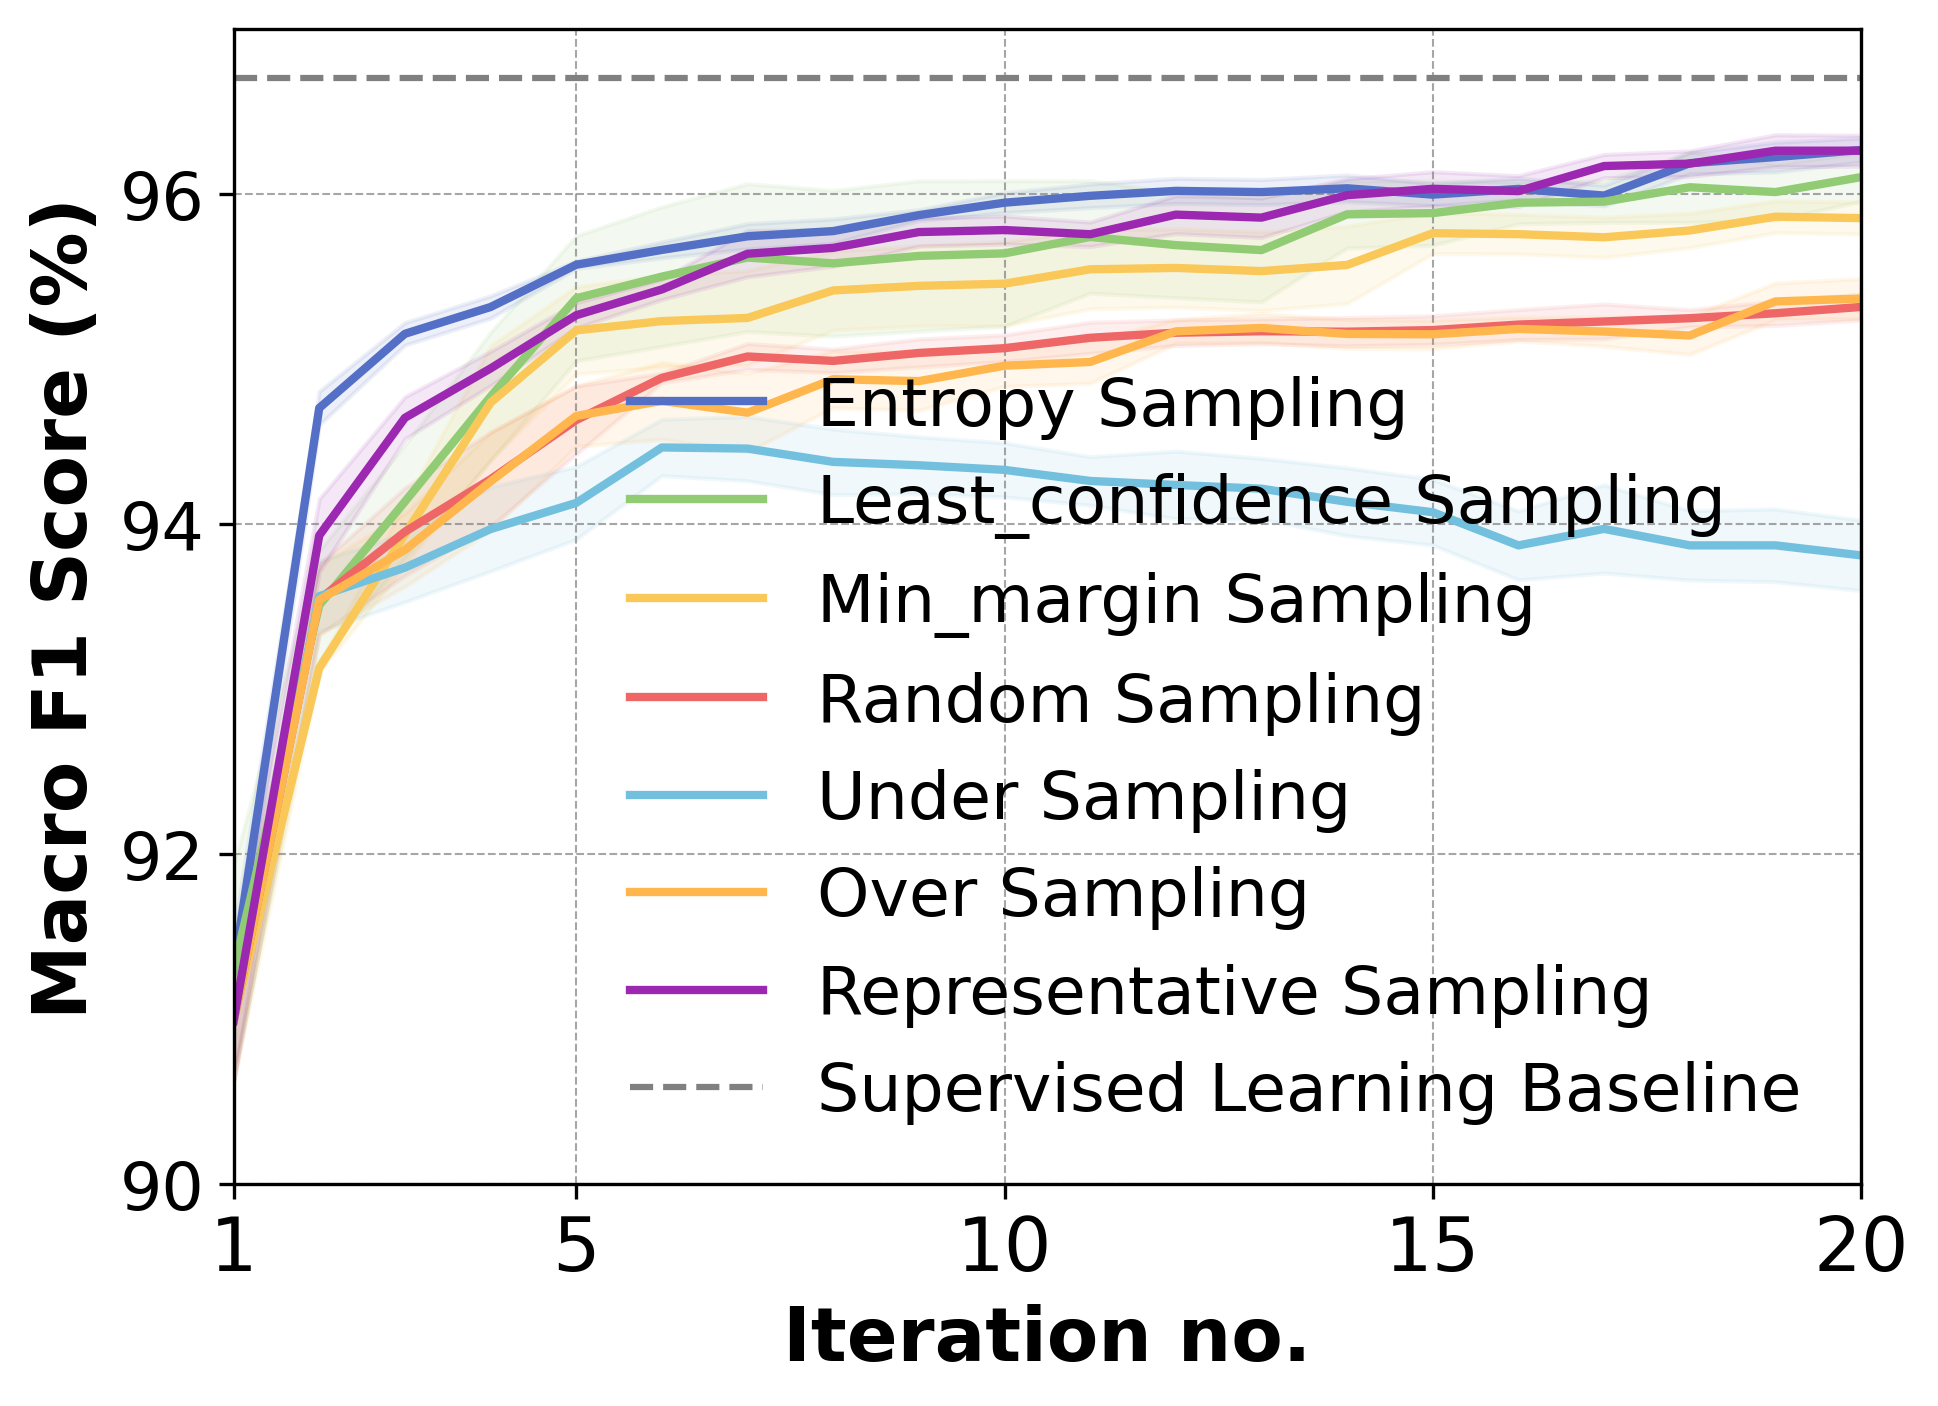

In [132]:
num_iterations = 20
# num_samples = 100  # 每次迭代预测的样本数
classes = [0, 1, 2, 3, 4, 5, 6]  # 7 个类别
# classes = [0, 1, 2, 3, 4]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

for i in range(num_iterations):
    for cls in classes:
        if cls == 0:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy_acc[sid][i])
                y_pred = np.concatenate(entropy_pred_label_lists[sid][i])
                y_true = np.concatenate(entropy_true_label_lists[sid][i])
                f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

                f1scores.append(f1)

            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 3:
            f1scores = []
            for sid in range(5):
                # f1scores.append(base_acc[sid][i])
                y_pred = np.concatenate(base_pred_label_lists[sid][i])
                y_true = np.concatenate(base_true_label_lists[sid][i])
                f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
                f1scores.append(f1)
                
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 4:
            f1scores = []
            for sid in range(5):
                # f1scores.append(underRandom_acc[sid][i])
                y_pred = np.concatenate(underRandom_pred_label_lists[sid][i])
                y_true = np.concatenate(underRandom_true_label_lists[sid][i])
                f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
                f1scores.append(f1)

            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 5:
            f1scores = []
            for sid in range(5):
                # f1scores.append(overAugment_acc[sid][i])
                y_pred = np.concatenate(overAugment_pred_label_lists[sid][i])
                y_true = np.concatenate(overAugment_true_label_lists[sid][i])
                f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
                f1scores.append(f1)
                
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 6:
            f1scores = []
            for sid in range(5):
                # f1scores.append(repreSamp_acc[sid][i])
                y_pred = np.concatenate(repreSamp_pred_label_lists[sid][i])
                y_true = np.concatenate(repreSamp_true_label_lists[sid][i])
                f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        if cls == 1:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = np.concatenate(entropy1_pred_label_lists[sid][i])
                y_true = np.concatenate(entropy1_true_label_lists[sid][i])
                f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        if cls == 2:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy2_acc[sid][i])
                y_pred = np.concatenate(entropy2_pred_label_lists[sid][i])
                y_true = np.concatenate(entropy2_true_label_lists[sid][i])
                f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
                f1scores.append(f1)
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        else:
            continue
            print('error')


# 画图
# fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 颜色匹配图例
colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    5: "#FFB74D",  # 橙色 - Category 5
    6: "#9C27B0",  # 紫色 - Category 6
    7: "#26A69A",  # 青绿色 - Category 7
    8: "#8D6E63",  # 棕色 - Category 8
    9: "#607D8B",  # 灰蓝色 - Category 9
}

labels = {0: 'Entropy Sampling',
          3: 'Random Sampling',
          4: 'Under Sampling',
          5: 'Over Sampling',
          6: 'Representative Sampling',
          1: 'Least_confidence Sampling',
          2: 'Min_margin Sampling',
          7: 'Supervised Learning Baseline',
          }

# 绘制每个类别的曲线
f1_scores[0][0] = f1_scores[1][0]
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls], linewidth=2)

    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.1)

# 添加supervised的虚线
file_name = 'Accel__supervisebase_seed2025_epoch99_results.pkl'  # 

supervise_acc = []
with open(os.path.join(root_path, file_name), 'rb') as f:
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    result_dict = pickle.load(f)
supervise_acc.append(result_dict['test_micro_f1_list'])

f1 = supervise_acc[0][49]
ax.axhline(y=f1*100,
           color='grey', linestyle="--", label=labels[7], linewidth=1.5)

# 标注轴标签
ax.set_xlabel("Iteration no.", fontsize=18, fontweight='bold')
ax.set_ylabel("Macro F1 Score (%)", fontsize=18, fontweight='bold')
ax.set_xticks([1, 5, 10, 15, 20])  # 设置刻度位置
ax.set_xticklabels(["1", "5", "10", "15", "20"], fontsize=18)  # 设置刻度标签

# 设置 y 轴刻度
yticks = np.arange(90, 97, 2)  # 设置刻度位置
ax.set_yticks(yticks)  # 应用刻度位置
# 设置 y 轴刻度标签
plt.gca().set_yticklabels([str(a) for a in yticks], fontsize=16)

# 网格线优化
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")
ax.set_xlim(1, num_iterations)
ax.set_ylim(90, 97)
# 添加图例
ax.legend(frameon=False, ncol=1, fontsize=16)

plt.show()

In [133]:
f1_scores[1][0]

91.29745718821691

In [123]:
root_path = r'D:\code\DeepView\deepview\calculate_results\data\bear'

# fig2的几个active learning比较

# active learning采用random sampling方法
base_acc = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__random_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
        result_dict3 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])
    base_selected_labels_list.append(result_dict3['selected_labels_list'])


# representative sampling
repreSamp_acc = []
repreSamp_pred_label_lists, repreSamp_true_label_lists, repreSamp_selected_labels_list = [], [], []
repreSamp_ari_list, repreSamp_nmi_list, repreSamp_fmi_list = [], [], []
repreSamp_silhouette_list, repreSamp_label_data_list, repreSamp_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__repreSamp_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    repreSamp_acc.append(result_dict['test_micro_f1_list'])
    repreSamp_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    repreSamp_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

    
underRandom_acc = []
underRandom_pred_label_lists, underRandom_true_label_lists = [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__underRandom_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    underRandom_acc.append(result_dict['test_micro_f1_list'])
    underRandom_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    underRandom_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
############
num_iterations = 20
# num_samples = 100  # 每次迭代预测的样本数
# classes = [0, 1, 2, 3, 4, 5, 6]  # 7 个类别
classes = [0, 1, 2]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

f1score_list = {}
# for i in range(num_iterations):
i = num_iterations - 1
for cls in classes:
    if cls == 0:
        f1scores = []
        for sid in range(5):
            # f1scores.append(entropy_acc[sid][i])
            y_pred = np.concatenate(base_pred_label_lists[sid][i])
            y_true = np.concatenate(base_true_label_lists[sid][i])
            f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

            f1scores.append(f1)

        f1score_list[cls] = f1scores
    elif cls == 1:
        f1scores = []
        for sid in range(5):
            # f1scores.append(repreSamp_acc[sid][i])
            y_pred = np.concatenate(repreSamp_pred_label_lists[sid][i])
            y_true = np.concatenate(repreSamp_true_label_lists[sid][i])
            f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
            f1scores.append(f1)
        
        f1score_list[cls] = f1scores
    elif cls == 2:
        f1scores = []
        for sid in range(5):
            # f1scores.append(repreSamp_acc[sid][i])
            y_pred = np.concatenate(underRandom_pred_label_lists[sid][i])
            y_true = np.concatenate(underRandom_true_label_lists[sid][i])
            f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
            f1scores.append(f1)
        
        f1score_list[cls] = f1scores
    else:
        continue
        # print('error')


labels = {0: 'Random Sampling',
          1: 'Representative Sampling',
          2: 'Under Sampling',
          3: 'Supervised Learning Baseline',
          }

# 绘制每个类别的曲线
for idx, cls in f1score_list.items():
    print('sampling method: %s: F1 Scores: %s' % (labels[idx], cls))


# 添加supervised的虚线
file_name = 'Accel__supervisebase_seed2025_epoch99_results.pkl'  # 

supervise_acc = []
with open(os.path.join(root_path, file_name), 'rb') as f:
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    pickle.load(f)
    result_dict = pickle.load(f)
supervise_acc.append(result_dict['test_micro_f1_list'])

f1 = supervise_acc[0][49]
print(f1)

sampling method: Random Sampling: F1 Scores: [0.9539945064070255, 0.9538801323668686, 0.9505457262663883, 0.955553200939877, 0.951845749383681]
sampling method: Representative Sampling: F1 Scores: [0.9594159637345916, 0.9627481719344325, 0.9659583392744596, 0.9619843515076903, 0.9630699714149148]
sampling method: Under Sampling: F1 Scores: [0.9424529937727064, 0.9423966447376574, 0.929363404474704, 0.9382550166175809, 0.9380691141985247]
0.9670541035571102


### 填充数据，作图

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Sequence

# ---------------------- Utilities ----------------------
def bootstrap_mean_ci(x: np.ndarray, n_boot=5000, ci=95, seed=0) -> Tuple[float, Tuple[float, float]]:
    """Return (mean_boot, [lo, hi]) using bootstrap percentiles."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return float("nan"), (float("nan"), float("nan"))
    rng = np.random.RandomState(seed)
    boots = rng.choice(x, size=(n_boot, x.size), replace=True).mean(axis=1)
    m = float(boots.mean())
    lo = float(np.percentile(boots, (100 - ci) / 2.0))
    hi = float(np.percentile(boots, 100 - (100 - ci) / 2.0))
    return m, (lo, hi)

def jitter(n, scale=0.045):
    return (np.random.rand(n) - 0.5) * 2 * scale

# ---------------------- Plot (single panel) ----------------------
def plot_single_panel(df: pd.DataFrame,
                      method_column: Sequence[str] = ("Baseline", "ALBE"),
                      out_png: str = "single_panel_ALBE_vs_baseline.png",
                      out_svg: str = "single_panel_ALBE_vs_baseline.svg") -> None:
    """
    Make a single-axis figure:
      - grouped methods (order given by `method_column`) for each dataset
      - seed jittered points, mean±95% CI, paired lines (if exactly 2 methods),
        100% ref line, Δ annotation (if exactly 2 methods)
    """
    # Basic validations
    needed = {"dataset", "method", "seed", "pct_of_supervised"}
    assert needed.issubset(df.columns), f"Missing columns: {needed - set(df.columns)}"

    # Method order & check
    methods = list(method_column)
    missing_methods = [m for m in methods if m not in set(df["method"].unique())]
    if len(missing_methods) > 0:
        raise AssertionError(f"`method_column`包含了数据中不存在的方法: {missing_methods}")

    # Sort and prepare
    datasets = sorted(df["dataset"].unique().tolist())
    df = df.copy()
    df["dataset"] = pd.Categorical(df["dataset"], categories=datasets, ordered=True)
    df["method"]  = pd.Categorical(df["method"],  categories=methods,  ordered=True)
    df.sort_values(["dataset", "method", "seed"], inplace=True)

    # Matplotlib style (no seaborn, no explicit colors)
    plt.rcParams.update({
        "font.size": 14,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
    })

    # fig, ax = plt.subplots(figsize=(8.2, 4.6), dpi=300)
    fig, ax = plt.subplots(figsize=(7, 4.6), dpi=300)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 100% reference line
    ax.axhline(100, ls="--", lw=0.9)

    x_ds = np.arange(len(datasets))

    # Offsets for arbitrary number of methods (symmetric around 0)
    # Keep total half-span similar to original dx=0.23 for 2 methods
    half_span = 0.23 if len(methods) >= 2 else 0.0
    if len(methods) > 1:
        offs_arr = np.linspace(-half_span, half_span, len(methods))
    else:
        offs_arr = np.array([0.0])
    offsets: Dict[str, float] = {m: float(offs_arr[i]) for i, m in enumerate(methods)}

    # Markers pool for multiple methods
    marker_pool = ["o", "s", "^", "D", "P", "X", "*", "v", "<", ">", "h", "H"]
    markers: Dict[str, str] = {m: marker_pool[i % len(marker_pool)] for i, m in enumerate(methods)}
    seed_size = 22

    all_vals = []
    delta_text = {}

    # Loop datasets to draw points, mean±CI, paired lines, and Δ annotation
    for i, ds in enumerate(datasets):
        dsi = df[df["dataset"] == ds]

        # Draw each method for this dataset
        per_method_vals = {}
        for m in methods:
            mdi = dsi[dsi["method"] == m].sort_values("seed")
            if len(mdi) == 0:
                continue
            vals = mdi["pct_of_supervised"].to_numpy(dtype=float)
            xs = np.full(vals.size, x_ds[i] + offsets[m]) + jitter(vals.size, 0.04)
            ax.scatter(xs, vals, s=seed_size, alpha=0.75, marker=markers[m],
                       linewidths=0, label=m if i == 0 else None)
            all_vals.extend(vals.tolist())

            mu, (lo, hi) = bootstrap_mean_ci(vals, seed=12345 + i + 100 * (1 + methods.index(m)))
            if np.isfinite(mu):
                ax.errorbar(x_ds[i] + offsets[m], mu,
                            yerr=[[mu - lo], [hi - mu]],
                            fmt="D", ms=5, capsize=3.0, lw=1.0)
            per_method_vals[m] = (mdi, vals)

        # Paired seed lines & Δ (only if exactly 2 methods and both present)
        if len(methods) == 2:
            m0, m1 = methods[0], methods[1]
            if m0 in per_method_vals and m1 in per_method_vals:
                base_df = per_method_vals[m0][0]
                comp_df = per_method_vals[m1][0]

                # paired seed lines (intersecting seeds only)
                common = sorted(set(base_df["seed"]).intersection(set(comp_df["seed"])))
                for s in common:
                    y1 = float(base_df.loc[base_df["seed"] == s, "pct_of_supervised"].iloc[0])
                    y2 = float(comp_df.loc[comp_df["seed"] == s, "pct_of_supervised"].iloc[0])
                    ax.plot([x_ds[i] + offsets[m0], x_ds[i] + offsets[m1]],
                            [y1, y2], lw=1.0, alpha=0.35)

                # Δ annotation (mean(methods[1] - methods[0]) ± 95% CI)
                if common:
                    b = base_df[base_df["seed"].isin(common)]["pct_of_supervised"].to_numpy(dtype=float)
                    a = comp_df[comp_df["seed"].isin(common)]["pct_of_supervised"].to_numpy(dtype=float)
                    delta = a - b
                    d_mu, (d_lo, d_hi) = bootstrap_mean_ci(delta, seed=54321 + i)
                    if np.isfinite(d_mu):
                        sign = "+" if d_mu >= 0 else ""
                        delta_text[ds] = f"Δ={sign}{d_mu:.1f} pp [{d_lo:.1f},{d_hi:.1f}]"
                    else:
                        delta_text[ds] = "Δ=NA"
                else:
                    delta_text[ds] = "Δ=NA"

    # Axes/labels
    ax.set_xticks(x_ds, datasets)
    plt.setp(ax.get_xticklabels(), rotation=20,ha='right', rotation_mode="anchor")
    
    ax.set_ylabel("% of fully-supervised (20% labels)")
    # ax.set_ylabel("F1 score: % of fully-supervised (20% labels)")
    ax.set_xlim(-0.6, len(datasets) - 0.4)

    # y-range with padding
    if all_vals:
        y_min = min(min(all_vals), 89.0)
        # y_max = max(max(all_vals), 101.5)
        y_max = 102
    else:
        y_min, y_max = 0, 100
    pad = max(2.5, 0.06 * (y_max - y_min))
    # ax.set_ylim(y_min - pad, y_max + 2.0 * pad)
    ax.set_ylim(y_min , y_max  + 0.3 * pad)

    # Δ text per dataset (top) if we computed it (exactly 2 methods)
    if len(methods) == 2:
        for i, ds in enumerate(datasets):
            y_top = ax.get_ylim()[1] - 0.018 * (ax.get_ylim()[1] - ax.get_ylim()[0])
            txt = delta_text.get(ds, "")
            if txt:
                ax.text(x_ds[i], y_top, txt, ha="center", va="top", fontsize=9)

    # Legend
    ax.legend(frameon=False, ncols=min(len(methods), 3), loc="lower right")

    ax.margins(x=0.02)
    plt.tight_layout()
    fig.savefig(out_svg)
    fig.savefig(out_png, dpi=400)
    print(f"Saved to: {out_svg}  /  {out_png}")

# ---------------------- Run (no args) ----------------------
# df = build_example_dataframe()           # <-- 用你的真实数据时，替换这行
# 例：保持两方法（顺序由method_column控制）
# plot_single_panel(df, method_column=("Baseline", "ALBE"))
# 例：三方法
# plot_single_panel(df, method_column=("Random", "SimCLR", "ALBE"))

Saved to: single_panel_ALBE_vs_baseline.svg  /  single_panel_ALBE_vs_baseline.png


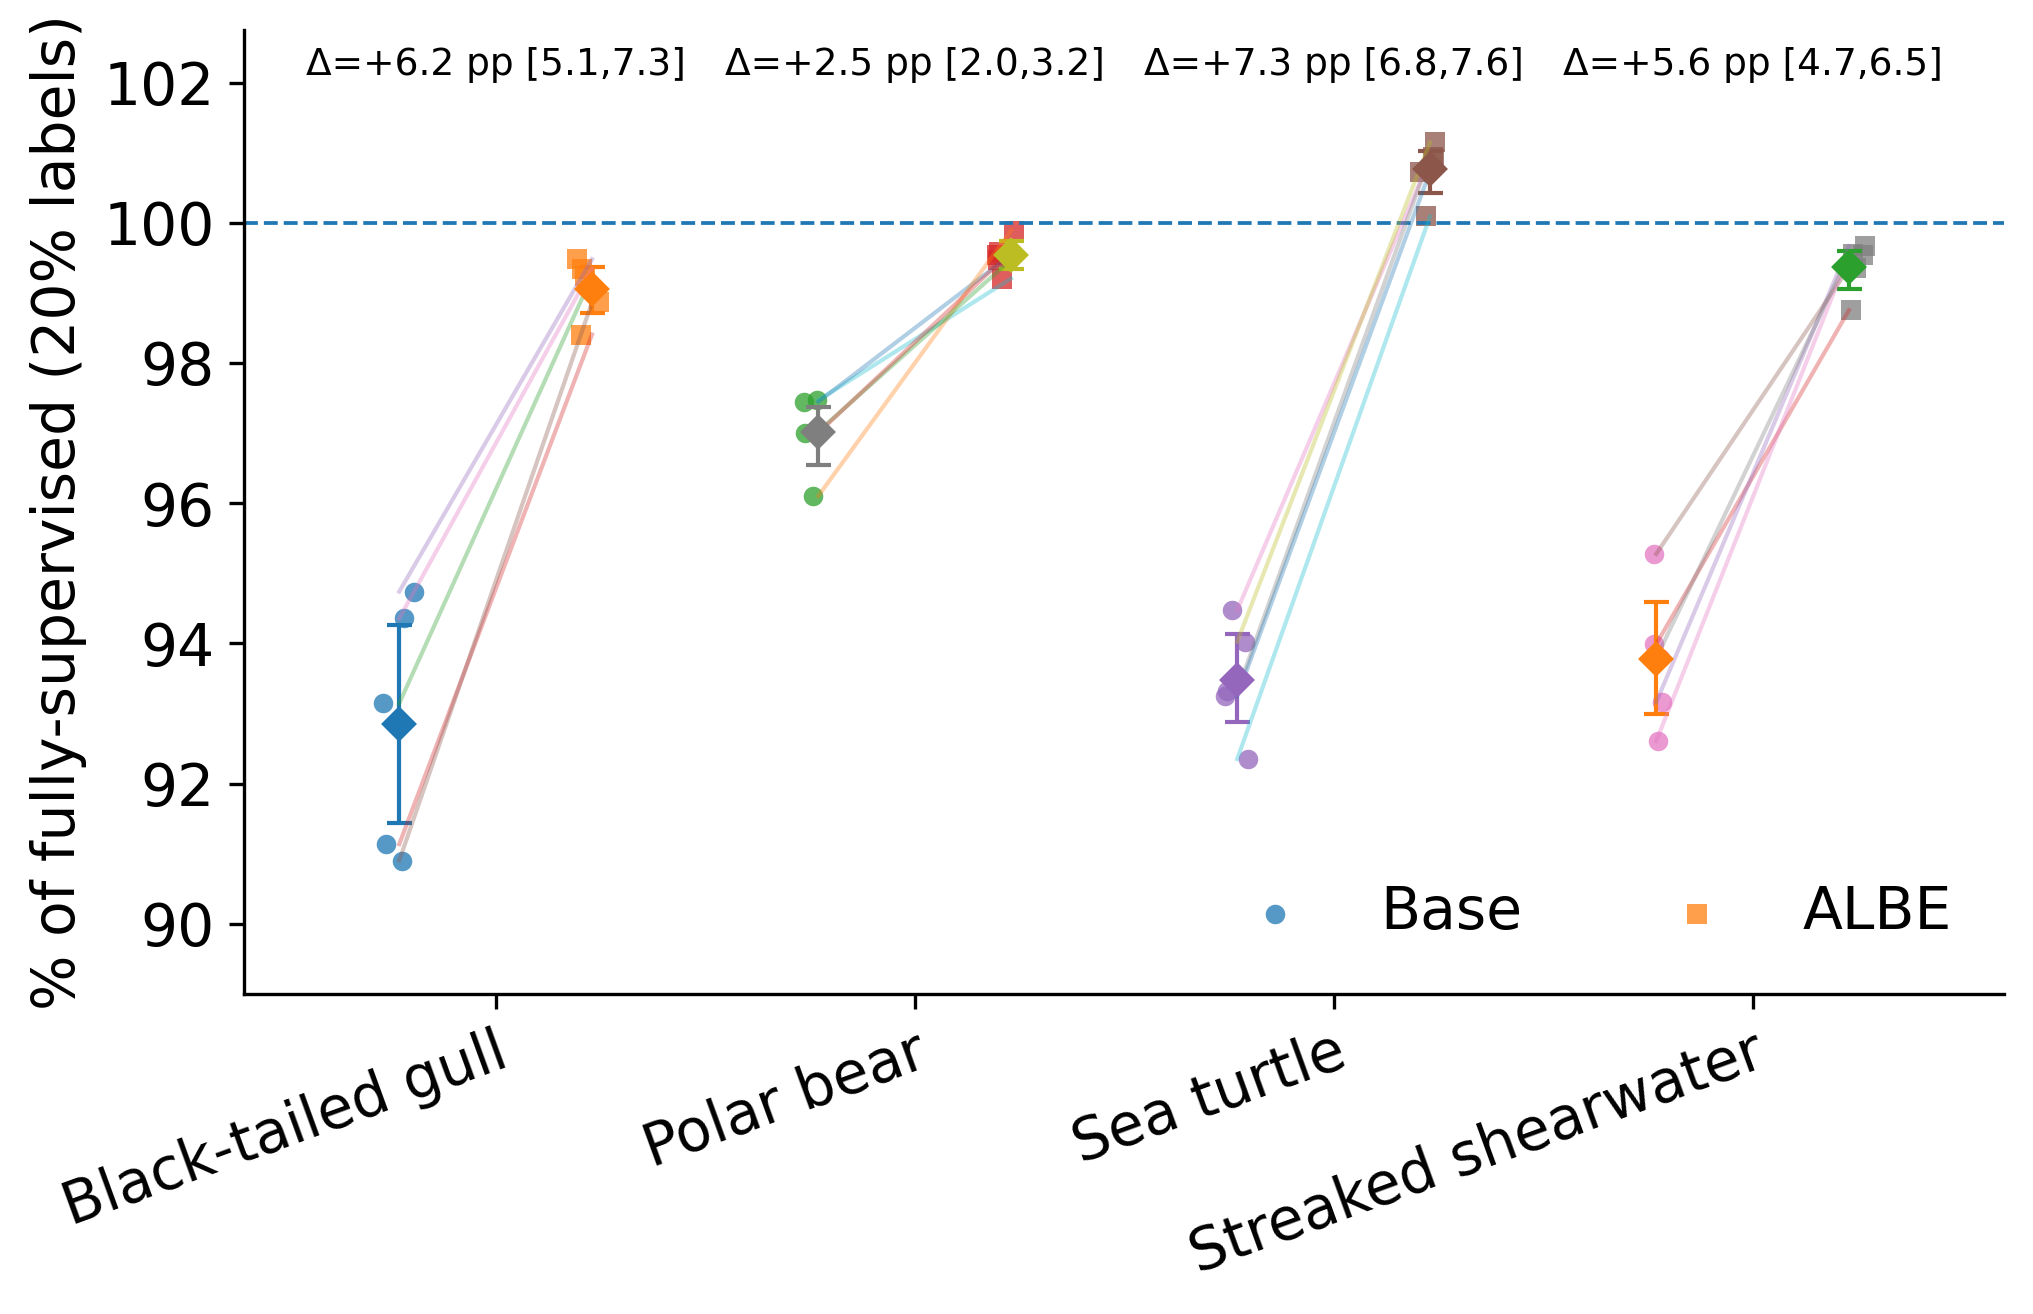

In [125]:
# 含每个 seed 的具体数值（单位：% of fully-supervised at 20% labels）
data_dict = {
    "Black-tailed gull": {
        # "Base": {0: 92.20, 1: 88.10, 2: 91.62, 3: 89.91, 4: 89.48},
        "Base": {0: 87.63, 1: 85.74, 2: 89.13, 3: 85.52, 4: 88.77},
        "ALBE":     {0: 93.36, 1: 92.58, 2: 93.59, 3: 93.01, 4: 93.46},
    },
    "Streaked shearwater": {
        # "Base": {0: 92.71, 1: 93.66, 2: 93.53, 3: 92.91, 4: 93.08},
        "Base": {0: 89.73, 1: 88.94, 2: 90.96, 3: 88.41, 4: 89.54},
        "ALBE":     {0: 94.28, 1: 95.15, 2: 94.86, 3: 95.04, 4: 95.03},
    },
    "Sea turtle": {  # turtle
        # "Base": {0: 87.85, 1: 87.39, 2: 86.79, 3: 88.05, 4: 88.11},
        "Base": {0: 84.10, 1: 83.07, 2: 83.70, 3: 82.21, 4: 83.01},
        "ALBE":     {0: 89.83, 1: 89.86, 2: 90.04, 3: 89.10, 4: 89.67},
    },
    "Polar bear": {  # bear
        # "Base": {0: 95.40, 1: 95.39, 2: 95.05, 3: 95.56, 4: 95.18},  # random sampling
        "Base": {0: 94.26, 1: 94.24, 2: 92.94, 3: 93.83, 4: 93.81},  # under sampling
        "ALBE":     {0: 95.94, 1: 96.27, 2: 96.60, 3: 96.20, 4: 96.31},
    },
}
supervised_dict = {
    "Black-tailed gull": 94.08,
    "Streaked shearwater": 95.47,
    "Sea turtle": 89.02,
    "Polar bear": 96.71,
}


# 如果你需要 DataFrame：
import pandas as pd
rows = []
for ds, methods in data_dict.items():
    for m, seedmap in methods.items():
        for s, v in seedmap.items():
            percet_v = (1- ((supervised_dict[ds] - v) / supervised_dict[ds])) *100  # 计算相对于全监督的百分比
            # print(percet_v)
            rows.append({"dataset": ds, "method": m, "seed": s, "pct_of_supervised": percet_v})
            # rows.append({"dataset": ds, "method": m, "seed": s, "pct_of_supervised": v})
df = pd.DataFrame(rows).sort_values(["dataset","method","seed"]).reset_index(drop=True)

# plot_single_panel(df, method_column=["Random", "ALBE"])
plot_single_panel(df, method_column=( "Base", "ALBE"))

In [75]:
percet_v

99.4106090373281